In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

In [2]:
ratings = pd.read_csv('../data/preprocessed/ratings_cleaned.csv')
movies = pd.read_csv('../data/preprocessed/movies_cleaned.csv')

In [3]:
# Convert the text back into lists for the 'genres' column
# ast.literal_eval safely converts the string "['A', 'B']" into an actual list ['A', 'B']
movies['genres'] = movies['genres'].apply(ast.literal_eval)

print(f"Data loaded! Ratings: {len(ratings)}, Movies: {len(movies)}")

Data loaded! Ratings: 989706, Movies: 9222


In [4]:
movies.sample(3)

,movieId,title,genres
5869,8125,Sunrise: A Song of Two Humans (1927),"[Drama, Romance]"
80,84,Last Summer in the Hamptons (1995),"[Comedy, Drama]"
6113,8813,We Don't Live Here Anymore (2004),[Drama]


In [5]:
ratings.sample(3)

,userId,movieId,rating,timestamp
933495,130491,1240,3.0,1999-12-22 04:42:59
456195,62134,954,4.0,2000-05-23 01:10:44
945943,131829,62956,4.0,2009-01-17 20:45:18


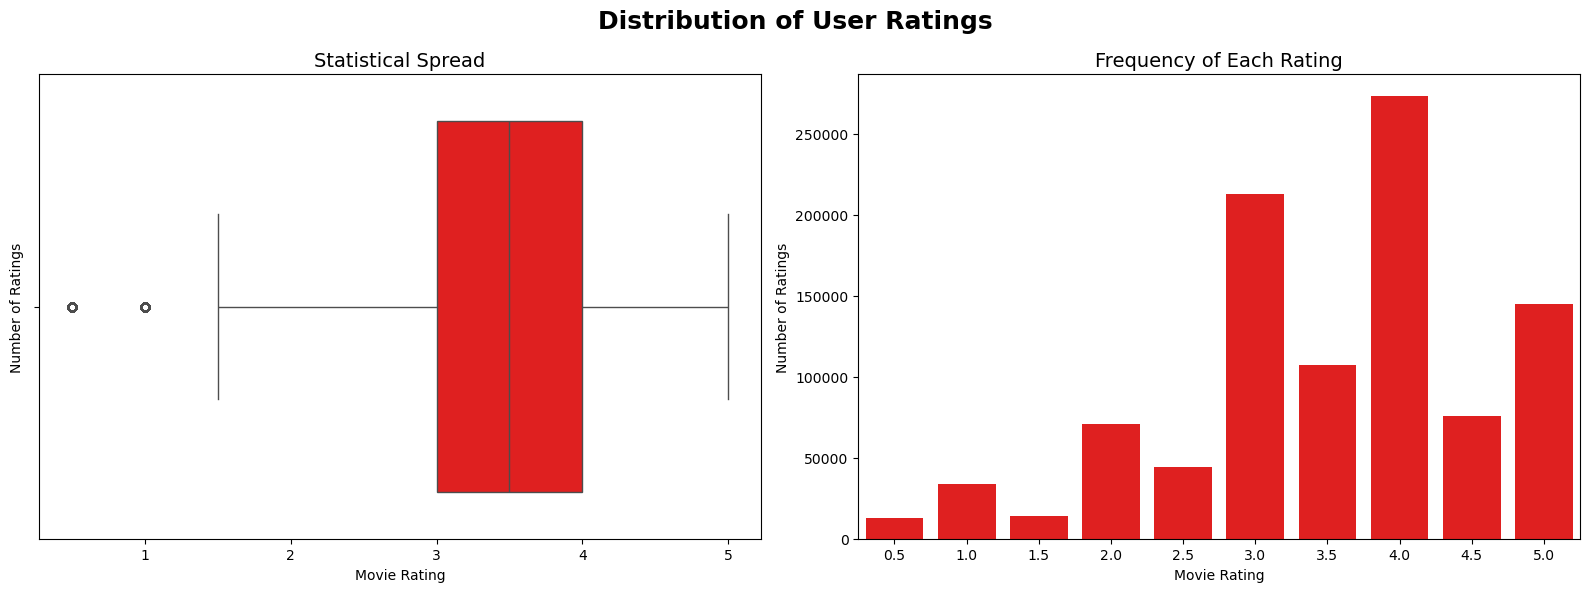

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=ax[0], data=ratings, x='rating',  color = 'r')
ax[0].set_title('Statistical Spread', fontsize=14)
ax[0].set_xlabel("Movie Rating")
ax[0].set_ylabel("Number of Ratings")

sns.countplot(ax=ax[1], data=ratings, x='rating', color = 'r')
ax[1].set_title('Frequency of Each Rating', fontsize=14)
ax[1].set_xlabel("Movie Rating")
ax[1].set_ylabel("Number of Ratings")

fig.suptitle('Distribution of User Ratings', fontsize=18, fontweight='bold')

plt.tight_layout()

In [7]:
n_users = ratings['userId'].nunique()

In [8]:
n_movies = movies['movieId'].nunique()

In [9]:
print(f"We have {n_users} unique users and {n_movies} unique films.")

We have 6924 unique users and 9222 unique films.


In [ ]:
ratings_per_user = ratings.groupby('userId').size().reset_index(name='num_ratings')

In [18]:
ratings_per_user['num_ratings'].describe()

count    6924.000000
mean      142.938475
std       229.761315
min        17.000000
25%        33.000000
50%        65.000000
75%       149.000000
max      3833.000000
Name: num_ratings, dtype: float64

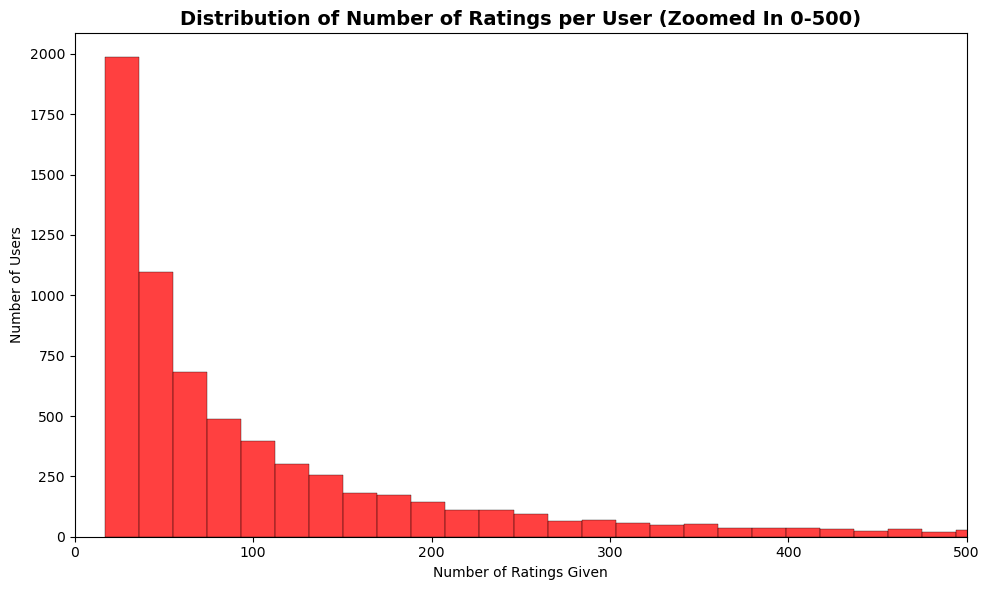

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(data=ratings_per_user, x='num_ratings', bins=200, color='r')

plt.xlim(0, 500)

plt.title('Distribution of Number of Ratings per User (Zoomed In 0-500)', fontsize=14, weight='bold')
plt.xlabel('Number of Ratings Given')
plt.ylabel('Number of Users')

plt.tight_layout()

In [13]:
genre_counts = {}

for x in movies['genres']:
    for y in x:
        if y in genre_counts:
            genre_counts[y] += 1
        else:
            genre_counts[y] = 1

In [14]:
count_per_genre = (
    pd.DataFrame.from_dict(genre_counts, orient='index')
    .reset_index()
    .sort_values(by=0, ascending=False)
    .rename(columns={"index" : "genre", 0: "count"})
)

In [15]:
count_per_genre.head(10)

,genre,count
6,Drama,4494
3,Comedy,3358
9,Thriller,1804
5,Romance,1598
7,Action,1589
8,Crime,1155
0,Adventure,1095
10,Horror,894
12,Sci-Fi,820
4,Fantasy,654


In [16]:
print(f"We have {len(count_per_genre)} unique genres.")

We have 19 unique genres.


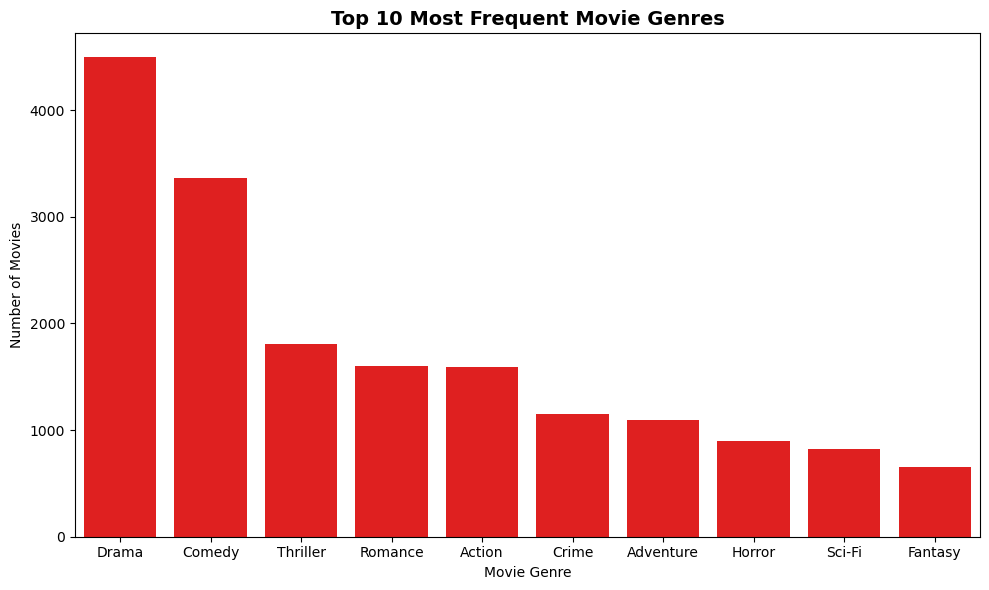

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(data=count_per_genre.head(10), x='genre', y='count', color='r')

plt.title("Top 10 Most Frequent Movie Genres", fontsize=14, weight='bold')
plt.xlabel("Movie Genre")
plt.ylabel("Number of Movies")

plt.tight_layout()